# 2.pmcx.run.stepbystep

This notebook runs the refactored MCX pipeline step-by-step using pmcx_utils. Set parameters in the next cell, then execute Stage 1 and Stage 2.

In [ ]:
!nvidia-smi

In [ ]:
import os
from pmcx_utils import run_stage1, run_stage2
# Optional: direct visualization helpers if needed
# from pmcx_utils import show_src_vol, view_result, view_result_mask

In [ ]:
!mkdir pmcx_temp_data
!cp -r /data1/syliu/work25_opensource_pre/m2m_20250614224327 pmcx_temp_data/m2m_20250614224327

In [ ]:
# ---- Parameters (edit as needed) ----
data_root_path="pmcx_temp_data/m2m_20250614224327"
path = os.path.join(data_root_path,"final_tissues.nii.gz")
subject_csv = os.path.join(data_root_path,"eeg_positions","EEG10-10_UI_Jurak_2007.csv")
seg_path = None  # Set to '/path/to/segmentation.nii.gz' for target mode
region_name = 'Fp1'
src_dir_mode = 'default'  
## one of ['default','fixed','target']
## default = from Fp1 point to most neighbor region in brain white+grey matter (centor of top1% neighbor region)
save_path = './results_run'

stage_2_mode = 'simple'  # one of ['full','simple']
# full = full computation 
# simple = 1e6 photons in total 
p = 250.0  # irradiance (mW)
t = 8.0     # time (mins)
# Optional source overrides
srctype = None        # e.g., 'disk'
srcparam1 = None      # e.g., [12,0,0,0]
srcparam2 = None      # e.g., [0,0,0,0]
# check if path exists
for p in [path,subject_csv]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Path {p} does not exist")
    else:
        print(f"Path {p} exists")

In [ ]:
# ---- Stage 1: compute source position and direction ----
stage1_inputs = {
    'path': path,
    'subject_csv': subject_csv,
    'seg_path': seg_path,
    'region_name': region_name,
    'src_dir_mode': src_dir_mode,
}
stage1_out = run_stage1(stage1_inputs)
stage1_out

In [ ]:
# ---- Stage 2: run MCX simulation and save outputs ----
custom_src = None
if srctype is not None:
    custom_src = {'srctype': srctype}
    if srcparam1 is not None: custom_src['srcparam1'] = srcparam1
    if srcparam2 is not None: custom_src['srcparam2'] = srcparam2

stage2_inputs = {
    'vol': stage1_out['vol'],
    'src_dir': stage1_out['src_dir'],
    'src_pos': stage1_out['src_pos'],
    'stage_2_mode': stage_2_mode,
    'custom_src': custom_src,
    'save_path': save_path,
    'p': p,
    't': t,
    'path': path,
}
stage2_out = run_stage2(stage2_inputs)
stage2_out['output_path']

Notes:

- Stage 2 produces interactive plots and saves NIfTI outputs in `save_path`.
- Ensure `pmcx` is installed and GPU is available/configured if needed.

Thu Oct  2 11:56:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:CA:00.0 Off |                  N/A |
| 55%   57C    P2            122W /  350W |    8024MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

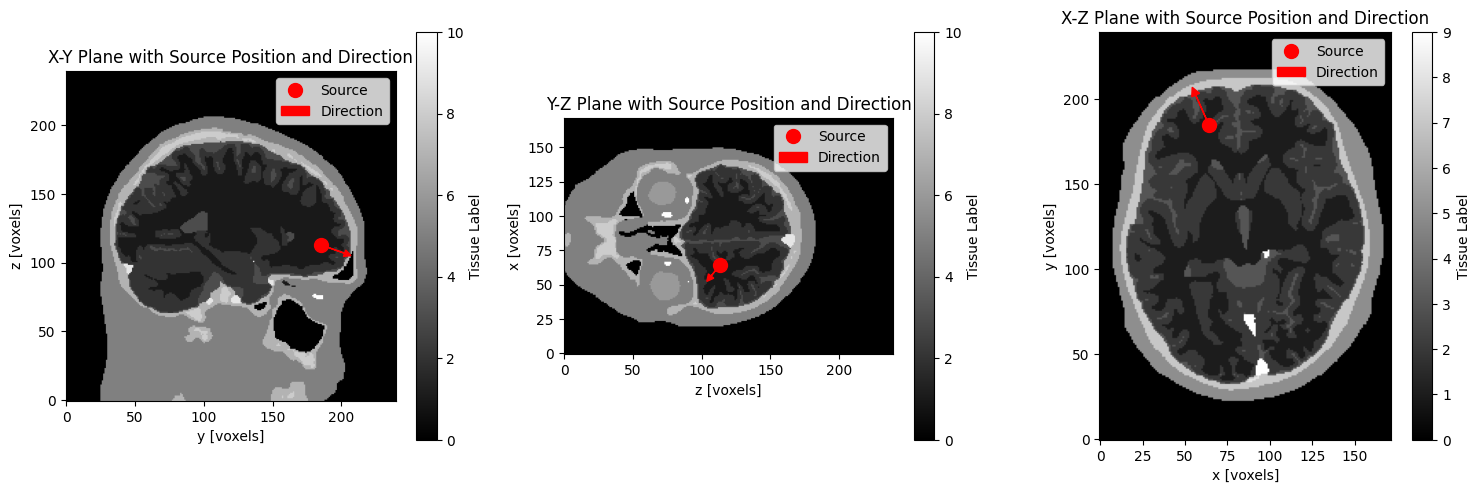

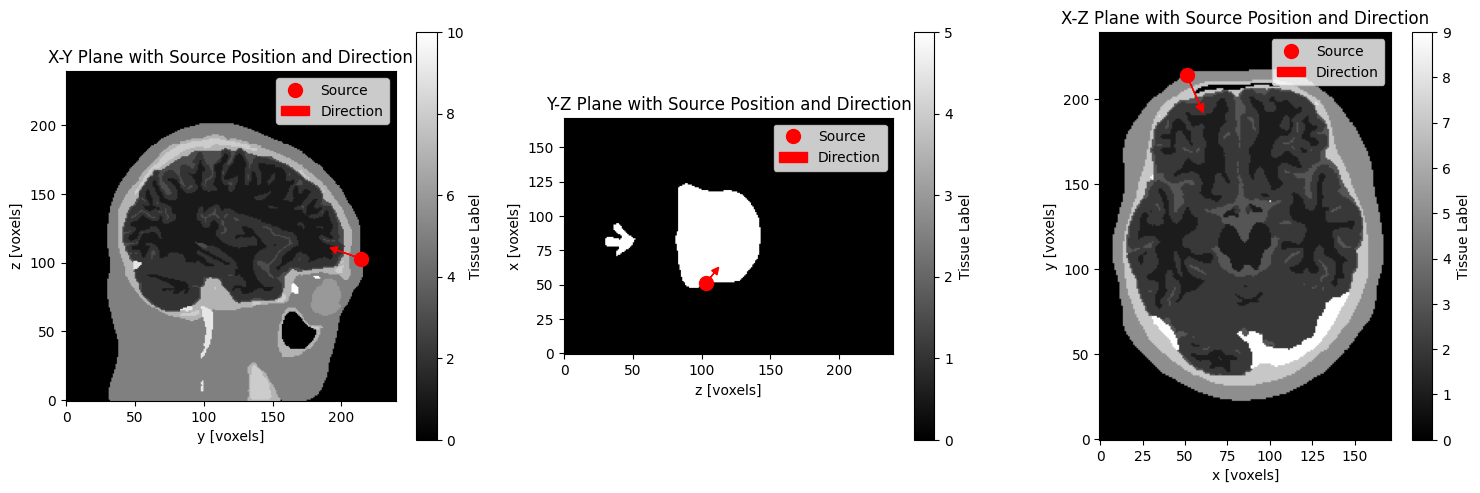

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
Stage 1 completed.
Running Stage 2 (simple mode)...
{'nphoton': 1000000.0, 'outputtype': 'energy', 'vol': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
  

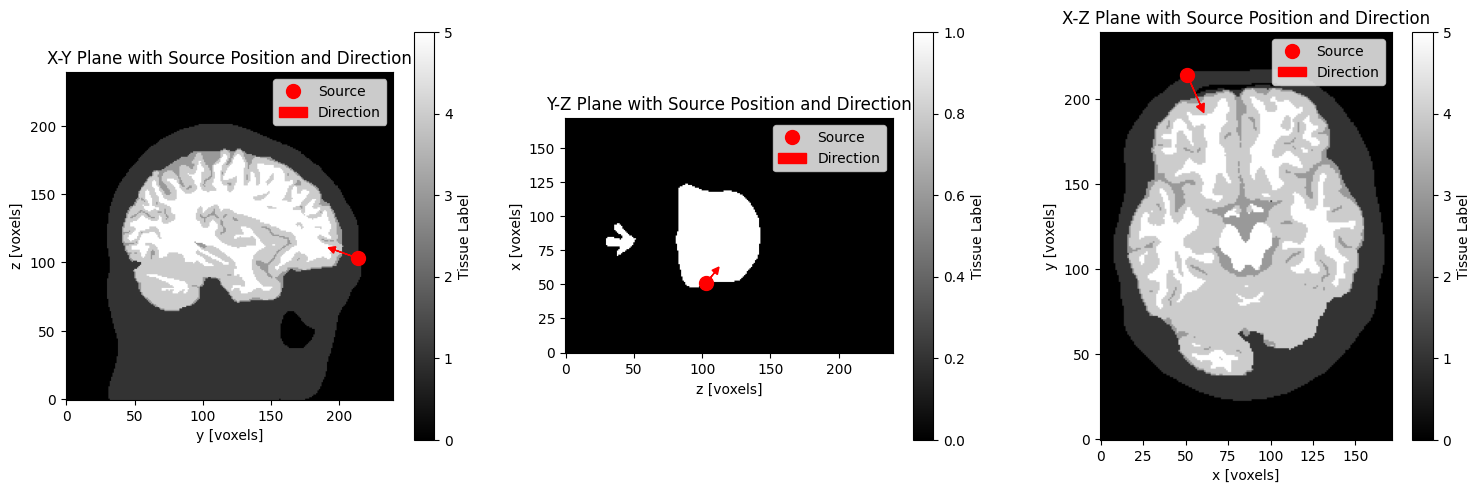

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
nphoton: 1e+06
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

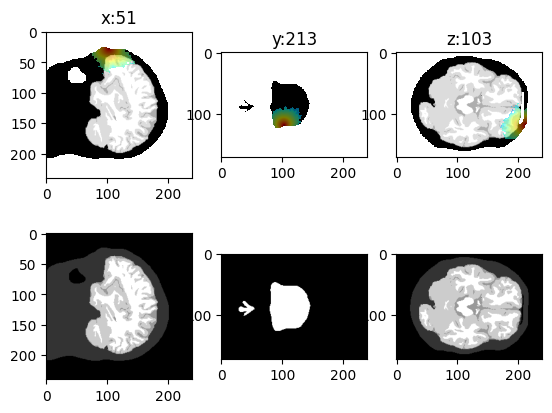

/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:121: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[best_slice_x, :, :])), cmap="gray")
/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:122: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[best_slice_x, :, :])), cmap="jet", alpha=0.5)
/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:127: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, best_slice_y, :])), cmap="gray")
/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:128: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(CWfluence[:, best_slice_y, :])), cmap="jet", alpha=0.5)
/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:133: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.flipud(np.log10(new_vol[:, :, best_slice_z])), cmap="gray")
/data1/syliu/ixi_mcx_2025/pmcx_utils/core.py:134: RuntimeWarning: divide by zero encou

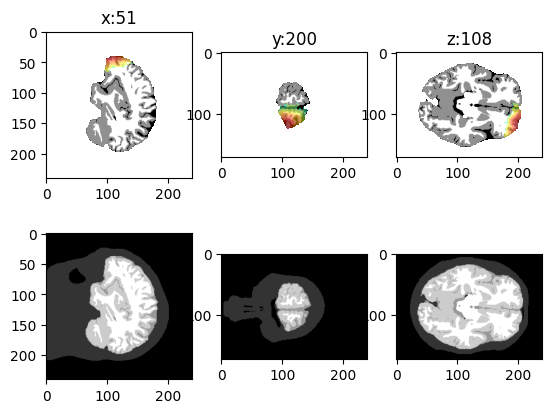

MCX results saved to ./results_run_simple
Simple mode outputs saved to: ./results_run_simple
Running Stage 2 (full mode)...
{'nphoton': 22302477099.15625, 'outputtype': 'energy', 'vol': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0,

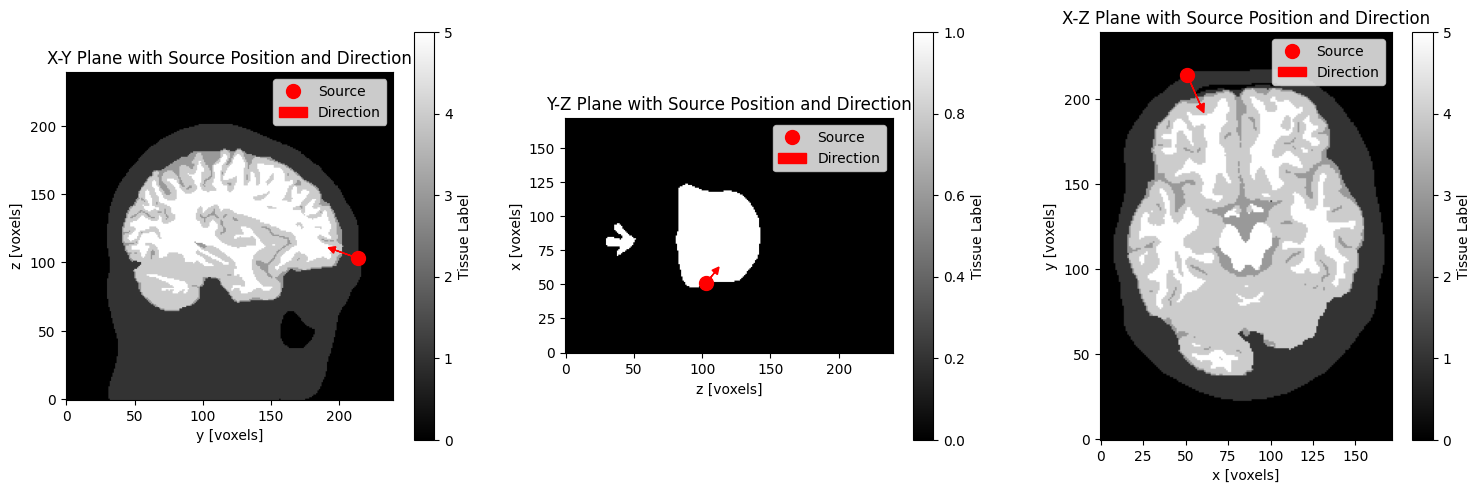

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
nphoton: 2.23025e+10
tstart: 0
tstep: 1e-09
tend: 1e-09
isreflect: 1
issrcfrom0: 1
autopilot: 1
isspecular: 0
srcnum: 1


###############################################################################
#                      Monte Carlo eXtreme (MCX) -- CUDA                      #
#          Copyright (c) 2009-2025 Qianqian Fang <q.fang at neu.edu>          #
#                https://mcx.space/  &  https://neurojson.io                  #
#                                                                             #
# Computational Optics & Translational Imaging (COTI) Lab- http://fanglab.org #
#   Department of Bioengineering, Northeastern University, Boston, MA, USA    #
###############################################################################
#    The MCX Project is funded by the NIH/NIGMS under grant R01-GM114365      #
###############################################################################
#  Open-source codes and reusable scientific data are essential for research, #
# MCX proudly developed human-readable JSON-based data formats for easy reuse.#
#                                       

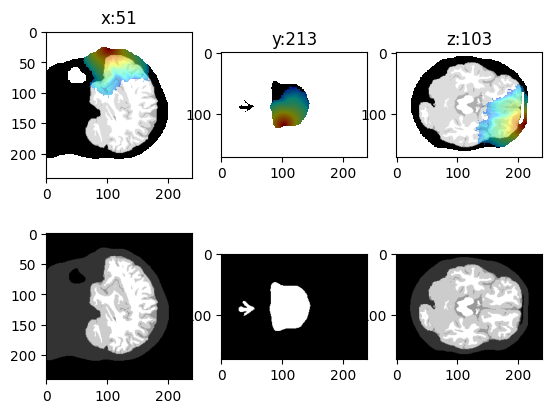

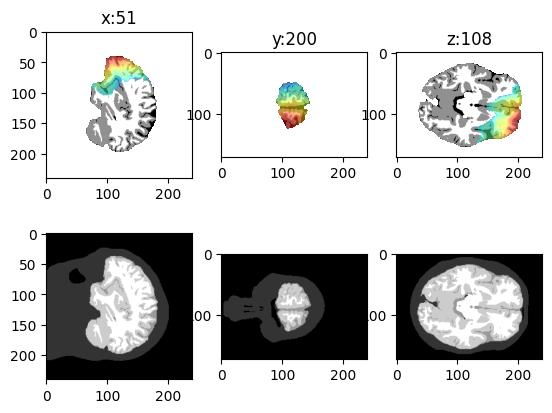

MCX results saved to ./results_run_full
Full mode outputs saved to: ./results_run_full
Done. Both modes have been executed.


In [ ]:
# 2.pmcx.run.both
# This script runs the refactored MCX pipeline twice: once in simple mode and once in full mode.
# Outputs are saved to separate directories: ./results_run_simple and ./results_run_full.

import os
import subprocess
from pmcx_utils import run_stage1, run_stage2

# Optional: check GPU status
try:
    subprocess.run(["nvidia-smi"])  # non-fatal if not available
except Exception:
    pass

# Prepare temp data (idempotent)
os.makedirs("pmcx_temp_data", exist_ok=True)
subprocess.run([
    "cp", "-r",
    "/data1/syliu/work25_opensource_pre/m2m_20250614224327",
    "pmcx_temp_data/m2m_20250614224327"
], check=False)

# Parameters
DATA_ROOT = "pmcx_temp_data/m2m_20250614224327"
path = os.path.join(DATA_ROOT, "final_tissues.nii.gz")
subject_csv = os.path.join(DATA_ROOT, "eeg_positions", "EEG10-10_UI_Jurak_2007.csv")
seg_path = None   # Provide for target mode if needed

region_name = "Fp1"
src_dir_mode = "default"  # one of ['default','fixed','target']

# Power/time
p = 250.0  # irradiance (mW)
t = 8.0    # time (mins)
# Optional source overrides
srctype = None        # e.g., 'disk'
srcparam1 = None      # e.g., [12,0,0,0]
srcparam2 = None      # e.g., [0,0,0,0]

# Check inputs
for chk in [path, subject_csv]:
    if not os.path.exists(chk):
        raise FileNotFoundError(f"Path {chk} does not exist")
    else:
        print(f"Path {chk} exists")

# Stage 1
stage1_inputs = {
    'path': path,
    'subject_csv': subject_csv,
    'seg_path': seg_path,
    'region_name': region_name,
    'src_dir_mode': src_dir_mode,
}
stage1_out = run_stage1(stage1_inputs)
print("Stage 1 completed.")

# Build custom source if provided
custom_src = None
if srctype is not None:
    custom_src = {'srctype': srctype}
    if srcparam1 is not None:
        custom_src['srcparam1'] = srcparam1
    if srcparam2 is not None:
        custom_src['srcparam2'] = srcparam2

# Stage 2 - simple
simple_save = "./results_run_simple"
stage2_simple = {
    'vol': stage1_out['vol'],
    'src_dir': stage1_out['src_dir'],
    'src_pos': stage1_out['src_pos'],
    'stage_2_mode': 'simple',
    'custom_src': custom_src,
    'save_path': simple_save,
    'p': p,
    't': t,
    'path': path,
}
print("Running Stage 2 (simple mode)...")
stage2_out_simple = run_stage2(stage2_simple)
print(f"Simple mode outputs saved to: {stage2_out_simple['output_path']}")

# Stage 2 - full
full_save = "./results_run_full"
stage2_full = {
    'vol': stage1_out['vol'],
    'src_dir': stage1_out['src_dir'],
    'src_pos': stage1_out['src_pos'],
    'stage_2_mode': 'full',
    'custom_src': custom_src,
    'save_path': full_save,
    'p': p,
    't': t,
    'path': path,
}
print("Running Stage 2 (full mode)...")
stage2_out_full = run_stage2(stage2_full)
print(f"Full mode outputs saved to: {stage2_out_full['output_path']}")

print("Done. Both modes have been executed.")